In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

print("All libraries loaded successfully!")

All libraries loaded successfully!


Step 1

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url)

titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Shape (rows, columns):", titanic_df.shape)
print()
titanic_df.info()

Shape (rows, columns): (891, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Step 2

In [4]:
# Step 2: Keep only useful columns
columns_to_use = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
titanic_df = titanic_df[columns_to_use]

# Check how many missing values each column has
titanic_df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


Step 3

In [5]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])

# Double check - should all be 0 now
titanic_df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


Step 4

In [6]:
titanic_df = pd.get_dummies(titanic_df, columns=["Sex", "Embarked"], drop_first=True)

titanic_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


Step 5

In [7]:
X = titanic_df.drop(columns=["Survived"])
y = titanic_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 712
Testing rows : 179


## PART 1 - Decision Tree Classifier


In [8]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)

print(f"Decision Tree Accuracy: {tree_accuracy:.2%}")

Decision Tree Accuracy: 78.77%


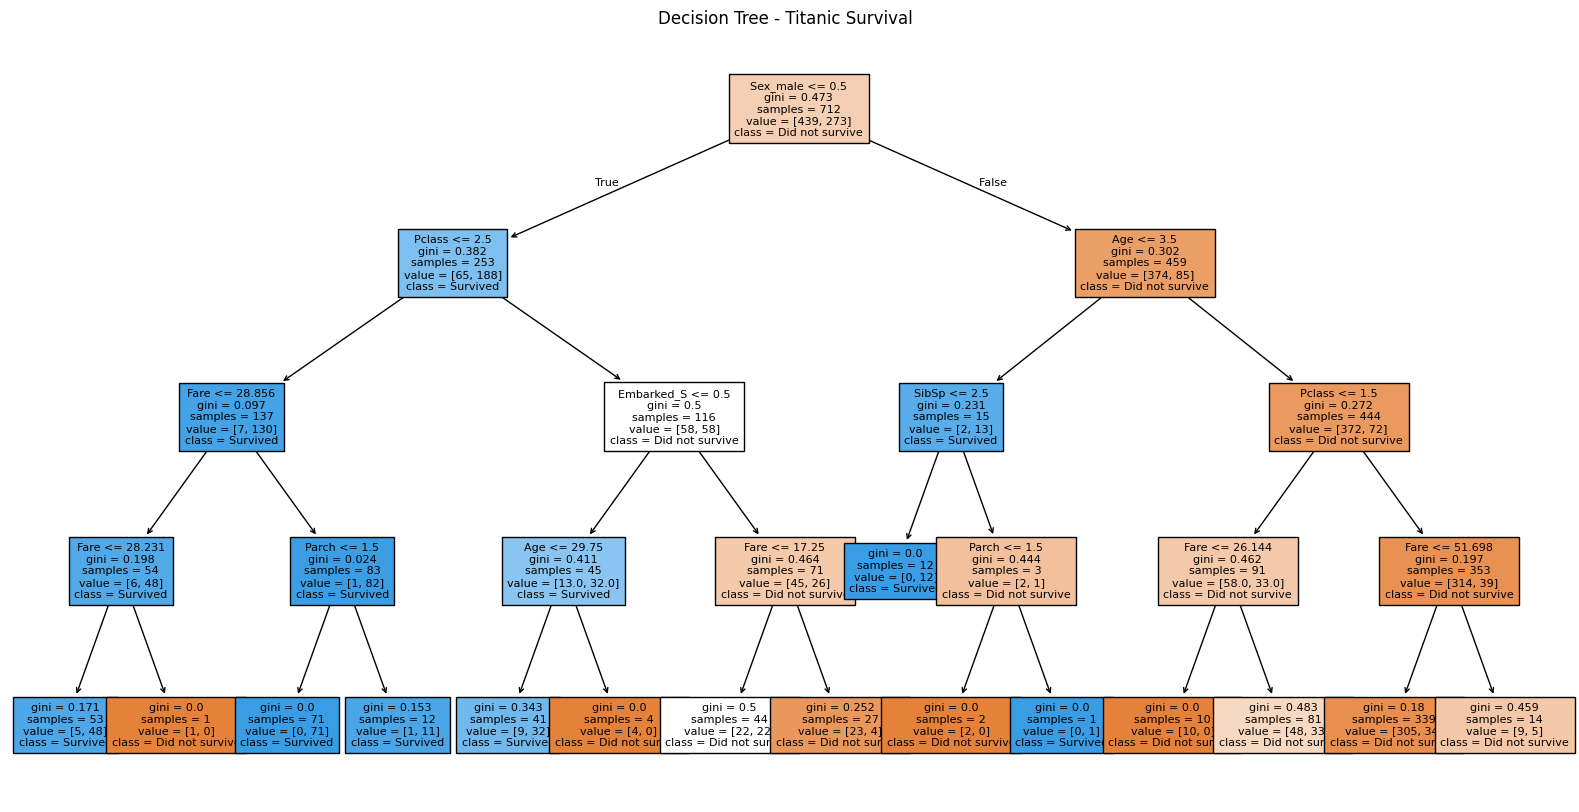

In [9]:
# Visualize the tree - you can literally read the questions it asks!
plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Did not survive", "Survived"],
    filled=True,
    fontsize=8
)
plt.title("Decision Tree - Titanic Survival")
plt.show()

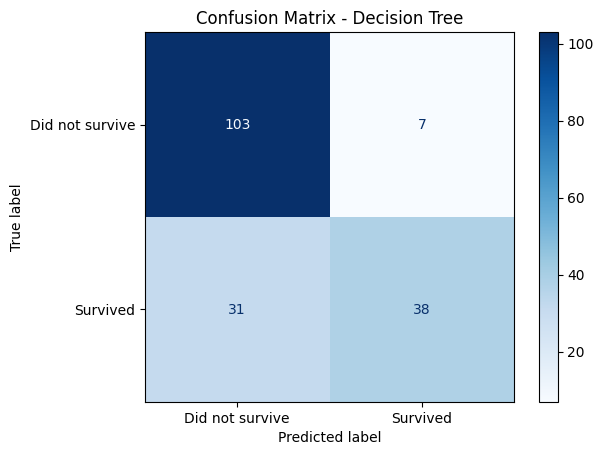

In [10]:
# Confusion matrix for the Decision Tree
cm_tree = confusion_matrix(y_test, tree_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

## PART 2 - Random Forest Classifier


In [12]:
forest_model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)
forest_accuracy = accuracy_score(y_test, forest_pred)

print(f"Random Forest Accuracy: {forest_accuracy:.2%}")

Random Forest Accuracy: 79.89%


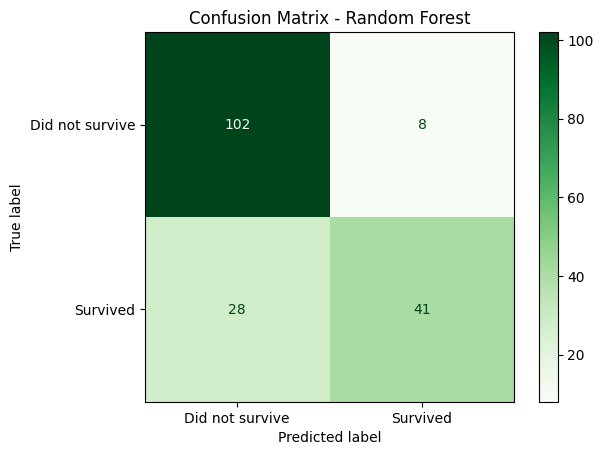

In [13]:
cm_forest = confusion_matrix(y_test, forest_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_forest, display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Step 6: Which features mattered most?

Random Forest can tell us which columns were most useful for making predictions — this is called **feature importance**.



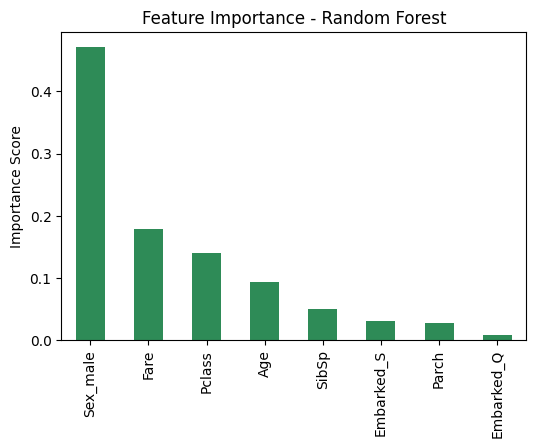

,0
Sex_male,0.472133
Fare,0.178702
Pclass,0.140356
Age,0.093978
SibSp,0.049356
Embarked_S,0.030325
Parch,0.027414
Embarked_Q,0.007736


In [14]:
importances = pd.Series(forest_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importances.plot(kind="bar", color="seagreen")
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()

importances

## Step 7: Compare Decision Tree vs Random Forest

In [15]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [tree_accuracy, forest_accuracy]
})
comparison

,Model,Accuracy
0,Decision Tree,0.787709
1,Random Forest,0.798883


## Step 8: Predict for a brand-new passenger

In [16]:
new_passenger = pd.DataFrame([{
    "Pclass": 1,
    "Age": 28,
    "SibSp": 0,
    "Parch": 0,
    "Fare": 100,
    "Sex_male": 0,      # 0 = female
    "Embarked_Q": 0,
    "Embarked_S": 1      # boarded from Southampton
}])

# Make sure column order matches training data
new_passenger = new_passenger[X.columns]

tree_result = tree_model.predict(new_passenger)[0]
forest_result = forest_model.predict(new_passenger)[0]

print("Decision Tree prediction:", "Survived" if tree_result == 1 else "Did not survive")
print("Random Forest prediction:", "Survived" if forest_result == 1 else "Did not survive")

Decision Tree prediction: Survived
Random Forest prediction: Survived


In [17]:
# Compare different max_depth values

for depth in [2, None]:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    print(f"max_depth={depth}: Accuracy = {accuracy:.2%}")

max_depth=2: Accuracy = 79.33%
max_depth=None: Accuracy = 81.56%


In [18]:
# Compare different numbers of trees

for n in [10, 300]:
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=4,
        random_state=42
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    print(f"n_estimators={n}: Accuracy = {accuracy:.2%}")

n_estimators=10: Accuracy = 79.89%
n_estimators=300: Accuracy = 78.77%


In [19]:
# Use passenger titles from the Name column

# Load the original Titanic dataset again
titanic_titles = pd.read_csv(url)

# Extract title from Name
titanic_titles["Title"] = titanic_titles["Name"].str.extract(r",\s*([^.]*)\.")

# Keep the original useful features + Title
columns_with_title = [
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "Title"
]

titanic_titles = titanic_titles[columns_with_title]

# Handle missing values
titanic_titles["Age"] = titanic_titles["Age"].fillna(
    titanic_titles["Age"].median()
)

titanic_titles["Embarked"] = titanic_titles["Embarked"].fillna(
    titanic_titles["Embarked"].mode()[0]
)

# Convert categorical columns into numbers
titanic_titles = pd.get_dummies(
    titanic_titles,
    columns=["Sex", "Embarked", "Title"],
    drop_first=True
)

# Separate features and target
X_title = titanic_titles.drop(columns=["Survived"])
y_title = titanic_titles["Survived"]

# Use the same train/test settings
X_title_train, X_title_test, y_title_train, y_title_test = train_test_split(
    X_title,
    y_title,
    test_size=0.2,
    random_state=42,
    stratify=y_title
)

# Train Random Forest
title_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

title_model.fit(X_title_train, y_title_train)

# Predict
title_pred = title_model.predict(X_title_test)

# Accuracy
title_accuracy = accuracy_score(y_title_test, title_pred)

print(f"Random Forest with Title Accuracy: {title_accuracy:.2%}")

Random Forest with Title Accuracy: 80.45%
